In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

In [5]:
index_names = ['unit_number', 'time_in_cycles']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

df = pd.read_csv("../CMAPSSData/train_FD001.txt", sep=r"\s+", header=None, names=col_names)

In [6]:
df['max_cycle'] = df.groupby('unit_number')['time_in_cycles'].transform('max')
df['RUL'] = df['max_cycle'] - df['time_in_cycles']
df["degradation_state"] = df["time_in_cycles"] / df["max_cycle"]
df = df.drop(columns = "max_cycle")

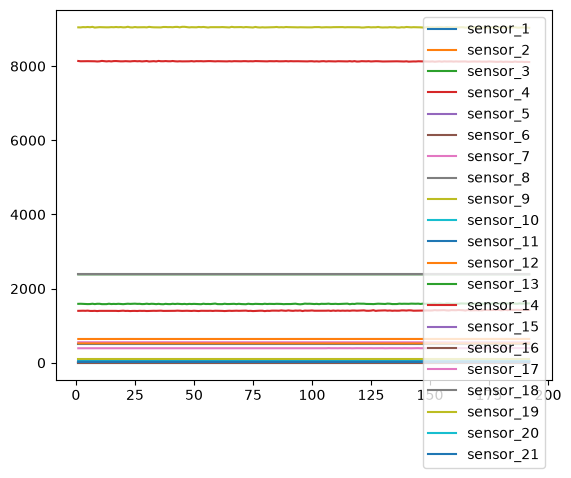

In [7]:
#checking how the sensor vary with each time in cycles for unit 1
#since unit 1 has max_cycle of 192
df1 = df[df["unit_number"] == 1]
for i in range(1, 22):
    plt.plot(df1["time_in_cycles"], df1[f"sensor_{i}"],label = f"sensor_{i}")
plt.legend()
plt.show()

In [8]:
#check the variance of the dataset 
variance = df[sensor_names].var()
print(variance)

sensor_1     0.000000e+00
sensor_2     2.500533e-01
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_5     2.840037e-29
sensor_6     1.929279e-06
sensor_7     7.833883e-01
sensor_8     5.038938e-03
sensor_9     4.876536e+02
sensor_10    0.000000e+00
sensor_11    7.133568e-02
sensor_12    5.439850e-01
sensor_13    5.172330e-03
sensor_14    3.639005e+02
sensor_15    1.406628e-03
sensor_16    1.203765e-35
sensor_17    2.398667e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    3.266927e-02
sensor_21    1.171825e-02
dtype: float64


In [9]:
constant_col = []
for col in sensor_names:
    if df[col].var() < 0.001:
        constant_col.append(col)
df_reduced = df.drop(columns = constant_col)
print(constant_col)

df_reduced.head()

['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL,degradation_state
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191,0.005208
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190,0.010417
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189,0.015625
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188,0.020833
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187,0.026042


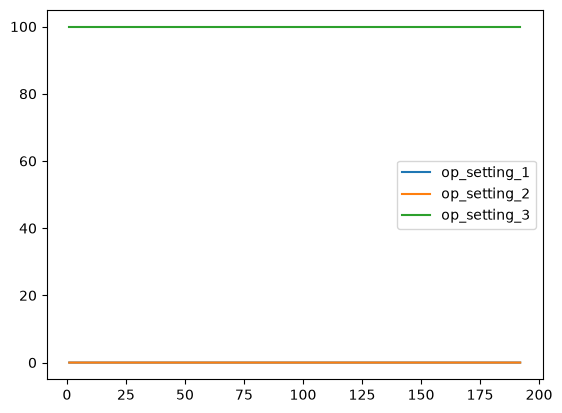

In [10]:
#do the same thing for op_settings
df1 = df[df["unit_number"] == 1]
for i in range(1, 4):
    plt.plot(df1["time_in_cycles"], df1[f"op_setting_{i}"],label = f"op_setting_{i}")
plt.legend()
plt.show()

In [11]:
# do the same for setting_names
setting_variance = df[setting_names].var()
print(setting_variance)
df_reduced_1 = df_reduced.drop(columns = setting_names)

op_setting_1    4.784340e-06
op_setting_2    8.588541e-08
op_setting_3    0.000000e+00
dtype: float64


In [17]:
unit_number_df = df_reduced_1.iloc[:, :2].copy()
cols = ["unit_number", "time_in_cycles", "RUL"]
df_final = df_reduced_1.drop(columns = cols)
unit_number_df.to_csv("../Data/metadata.csv", index = False)
print('files saved')

files saved


In [14]:
def pre_process():
    x = df_final.iloc[:, :-1].values
    Y = df_final['degradation_state'].values

    scaler = MinMaxScaler()
    X = scaler.fit_transform(x)
    return X, Y, scaler

In [15]:
X, Y, scaler = pre_process()

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (20631, 14)
Y shape: (20631,)


In [16]:
np.save("../Data/X_train", X)
np.save("../Data/Y_train", Y)

joblib.dump(scaler, "../Data/scaler.pkl")

print("files saved sucessfully")

files saved sucessfully
